# [VERSÃO 7] Classificação de Tumores Cerebrais — Treino com Múltiplas Execuções

Este notebook treina um modelo de classificação de tumores cerebrais
(EfficientNetB0 + Transfer Learning) várias vezes, com sementes/seeds
diferentes, para medir a **variabilidade** das métricas (acurácia,
precisão, recall e F1) e calcular a **média ± desvio padrão** de cada uma.

Roda no **Google Colab**, com o dataset baixado via `kagglehub`
(`mohammadhossein77/brain-tumors-dataset`) e as imagens processadas em
**224x224**. As imagens são pré-segmentadas uma única vez em disco local
(Otsu + maior componente conectado + convex hull preenchido) antes do
split treino/validação/teste, para evitar gargalo de CPU durante o treino.
A busca de hiperparâmetros (Hyperband) é ajustada para consumir poucas
unidades de processamento do Colab, e cada execução salva seus gráficos de
loss/acurácia. Os resultados são salvos em `Projeto/Desv_Hip/224x224/` no
Drive.

## Estrutura do notebook
1. Configuração do ambiente e do dataset (rodar 1x)
2. Preparação dos dados (`tf.data`) (rodar 1x)
3. Definição da arquitetura do modelo (função reutilizável)
4. Função que treina + avalia o modelo para uma seed (fases 1 e 2)
5. Loop de múltiplas execuções, com salvamento incremental
6. Cálculo da média e do desvio padrão das métricas
7. Matriz de confusão da melhor execução



## 1. Configuração do ambiente e download do dataset

Use GPU nesta seção (Ambiente de execução -> Alterar tipo de ambiente de execução -> GPU).


In [ ]:
# --------------------------------------------------------------
# 1.1. Montar o Google Drive e definir as pastas do projeto
# --------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = '/content/drive/MyDrive/Projeto/Desv_Hip'

# Como o tamanho de imagem mudou (128x128 -> 224x224), usamos uma subpasta
# separada para esta versão. Isso evita dois problemas: misturar hiperparâmetros
# do Hyperband otimizados para um tamanho de imagem diferente, e o loop da
# seção 5 "pular" uma seed achando que ela já foi treinada, quando na verdade
# é um experimento diferente (mesma seed, imagem diferente).
RUN_DIR = os.path.join(BASE_DIR, '224x224')
os.makedirs(RUN_DIR, exist_ok=True)
print(f"Resultados desta versão serão salvos em: {RUN_DIR}")


Mounted at /content/drive
Resultados desta versão serão salvos em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224


In [ ]:
# --------------------------------------------------------------
# 1.2. Importações principais
# --------------------------------------------------------------
import json
import random

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import tensorflow as tf

from tensorflow import keras
from keras import callbacks, layers, applications
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.applications import EfficientNetB0
from tensorflow.keras import regularizers

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

# --------------------------------------------------------------
# 1.3. Download do dataset (Kaggle) e coleta dos caminhos das imagens
#      No Colab, se pedir autenticação, rode antes: kagglehub.login()
#      (cola o token quando solicitado) ou configure os Secrets do Colab
#      com KAGGLE_USERNAME / KAGGLE_KEY.
# --------------------------------------------------------------
# O dataset é organizado em pastas por classe. Aqui percorremos todas as
# subpastas, guardamos o caminho de cada imagem e o nome da pasta (=rótulo).
path = kagglehub.dataset_download("mohammadhossein77/brain-tumors-dataset")
print("Caminho do dataset:", path)

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

image_paths = []
labels_raw = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(valid_extensions):
            image_paths.append(os.path.join(root, file))
            labels_raw.append(os.path.basename(root))  # nome da pasta = classe

# --------------------------------------------------------------
# 1.4. Mapear nomes das classes para índices numéricos
# --------------------------------------------------------------
class_names_list = sorted(list(set(labels_raw)))
num_classes = len(class_names_list)
class_to_label = {name: i for i, name in enumerate(class_names_list)}

labels = np.array([class_to_label[name] for name in labels_raw])
image_paths = np.array(image_paths)

print(f"\nTotal de imagens encontradas: {len(image_paths)}")
print(f"Classes identificadas: {class_names_list}")
for name, idx in class_to_label.items():
    count = list(labels_raw).count(name)
    print(f" - {name}: {count} imagens")


100%|██████████| 221M/221M [00:01<00:00, 124MB/s]

Extracting files...


Caminho do dataset: /root/.cache/kagglehub/datasets/mohammadhossein77/brain-tumors-dataset/versions/3

Total de imagens encontradas: 21672
Classes identificadas: ['Normal', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']
 - Normal: 3066 imagens
 - glioma_tumor: 6307 imagens
 - meningioma_tumor: 6391 imagens
 - pituitary_tumor: 5908 imagens


## 1.5. Pré-segmentação das imagens em disco local (evita gargalo de CPU/GPU)

**Correção de performance:** antes, a segmentação (OpenCV) era feita dentro do
pipeline `tf.data` (via `tf.py_function`), rodando em CPU **a cada batch, em
tempo de execução**. Isso deixa a GPU T4 ociosa a maior parte do tempo
esperando a CPU (gargalo de I/O/CPU), o que pode multiplicar o tempo de treino
por 3x-5x — ou seja, desperdiça Unidades de Processamento do Colab.

Aqui a segmentação é feita **uma única vez**, para todas as imagens, e o
resultado é salvo no SSD local da VM (`/content/dataset_segmentado`). Do
bloco 2 em diante, `image_paths` passa a apontar para essas imagens já
segmentadas, e o pipeline `tf.data` só precisa ler o arquivo e redimensionar
(sem OpenCV, sem `tf.py_function`).

Guardamos os caminhos originais em `image_paths_originais` para que os testes
visuais de segmentação (seção "TESTES DE SEGMENTAÇÃO", no fim do notebook)
continuem comparando "original" vs. "segmentado" corretamente.


In [ ]:
# --------------------------------------------------------------
# 1.5.1. Função de segmentação com OpenCV
#      Otsu (separa objeto do fundo por intensidade) + maior componente
#      conectado (remove ruído solto) + CONVEX HULL preenchido.
#      O convex hull é o que resolve o principal problema do Otsu puro:
#      como o Otsu decide pixel a pixel só pela intensidade, um tumor
#      com brilho parecido com o fundo podia "sumir" junto (virar buraco
#      na máscara). Preenchendo o fecho convexo do contorno externo do
#      cérebro, garantimos que nada DENTRO do contorno seja excluído,
#      independente da intensidade interna.
#      (Validado visualmente comparando várias variantes antes de trocar
#      a versão usada no pipeline — ver testes na seção "TESTES DE SEGMENTAÇÃO".)
#      Movida para cá (seção 1.5) para poder ser reaproveitada na
#      pré-segmentação em lote, antes do split treino/val/teste.
# --------------------------------------------------------------
def segment_image_cv(image_tensor):
    img = image_tensor.numpy().astype(np.uint8) if hasattr(image_tensor, 'numpy') else image_tensor.astype(np.uint8)

    # Se a imagem vier com shape (1, 224, 224, 3), remove a dimensão extra
    if len(img.shape) == 4:
        img = np.squeeze(img, axis=0)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # Threshold automático (Otsu) para separar objeto do fundo
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Mantém só o maior componente conectado (remove ruído solto do fundo)
    n_labels, labels_img, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=8)
    if n_labels > 1:  # label 0 é sempre o fundo
        maior_componente = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        thresh = np.where(labels_img == maior_componente, 255, 0).astype(np.uint8)

    # Preenche o fecho convexo do contorno externo — garante que nada
    # dentro do cérebro (ex.: tumor com intensidade parecida ao fundo)
    # seja cortado pela máscara.
    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contornos:
        maior_contorno = max(contornos, key=cv2.contourArea)
        hull = cv2.convexHull(maior_contorno)
        thresh_hull = np.zeros_like(thresh)
        cv2.drawContours(thresh_hull, [hull], -1, 255, thickness=cv2.FILLED)
        thresh = thresh_hull

    # Aplica a máscara resultante sobre a imagem original
    segmented = cv2.bitwise_and(img, img, mask=thresh)
    return segmented.astype(np.float32)

# --------------------------------------------------------------
# 1.5.2. Pré-segmentar e salvar todas as imagens no SSD local
#        (`/content/...` é o disco local da VM do Colab, bem mais rápido
#        que ler/escrever direto no Drive; e como é feito uma única vez,
#        deixa de pesar no tempo de cada época de treino)
# --------------------------------------------------------------
from tqdm import tqdm

IMAGE_SIZE = (224, 224)
PROCESSED_DIR = '/content/dataset_segmentado'
os.makedirs(PROCESSED_DIR, exist_ok=True)

image_paths_originais = image_paths.copy()  # mantém os caminhos originais (usados nos testes visuais)

print("Pré-processando e segmentando imagens para o SSD local...")
new_image_paths = []

for p in tqdm(image_paths_originais):
    # Gera um caminho único e "achatado" em disco local a partir do caminho original
    rel_path = os.path.relpath(p, path).replace(os.sep, '_')
    out_path = os.path.join(PROCESSED_DIR, rel_path)

    if not os.path.exists(out_path):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMAGE_SIZE)
        img_segmentado = segment_image_cv(img).astype(np.uint8)
        cv2.imwrite(out_path, cv2.cvtColor(img_segmentado, cv2.COLOR_RGB2BGR))

    new_image_paths.append(out_path)

# A partir daqui, `image_paths` aponta para as versões já segmentadas em disco
# local — é o que será usado no split (2.3) e no pipeline `tf.data` (2.6).
image_paths = np.array(new_image_paths)

print(f"Concluído: {len(image_paths)} imagens segmentadas e salvas em {PROCESSED_DIR}")


Pré-processando e segmentando imagens para o SSD local...


100%|██████████| 21672/21672 [01:03<00:00, 340.69it/s]

Concluído: 21672 imagens segmentadas e salvas em /content/dataset_segmentado


## 2. Preparação dos dados: split treino/val/teste e pipeline `tf.data`

In [ ]:
# --------------------------------------------------------------
# 2.1. Configurações gerais de imagem
# --------------------------------------------------------------
IMAGE_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

# --------------------------------------------------------------
# 2.2. Segmentação
#      A função `segment_image_cv` e a pré-segmentação em lote (que salva
#      as imagens já segmentadas no SSD local, em `/content/dataset_segmentado`)
#      foram movidas para a seção 1.5, para rodar uma única vez, ANTES do
#      split e da criação dos `tf.data.Dataset`. Isso evita reprocessar a
#      mesma imagem em CPU a cada batch/época (o que deixava a GPU T4
#      ociosa boa parte do tempo). Daqui em diante, `image_paths` já
#      aponta para as imagens segmentadas.
# --------------------------------------------------------------

# --------------------------------------------------------------
# 2.3. Split em treino / validação / teste (80% / 10% / 10%)
#      stratify=labels garante que a proporção de classes seja mantida
# --------------------------------------------------------------
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_paths, test_labels, test_size=0.5, random_state=42, stratify=test_labels
)

print(f"Treino: {len(train_paths)} | Validação: {len(val_paths)} | Teste: {len(test_paths)}")

# --------------------------------------------------------------
# 2.4. Salvar os caminhos/rótulos do split no Drive (dentro de RUN_DIR)
#      Isso é essencial: a seção 7 (matriz de confusão) roda depois,
#      possivelmente em outra sessão, e precisa recarregar EXATAMENTE o
#      mesmo conjunto de teste usado durante o treino.
# --------------------------------------------------------------
DADOS_DIR = os.path.join(RUN_DIR, 'resultados')
os.makedirs(DADOS_DIR, exist_ok=True)

np.save(os.path.join(DADOS_DIR, 'test_paths.npy'), test_paths)
np.save(os.path.join(DADOS_DIR, 'test_labels.npy'), test_labels)
print(f"Caminhos e rótulos do conjunto de teste salvos em {DADOS_DIR}")

# --------------------------------------------------------------
# 2.5. Data augmentation (aplicada apenas no conjunto de treino)
#      Observação: NÃO incluímos RandomFlip("vertical") nem rotações
#      grandes — um cérebro invertido de cabeça para baixo ou girado
#      demais não é uma variação anatomicamente plausível, e treinar
#      com isso pode ensinar o modelo a reconhecer padrões que não
#      existem em exames reais.
# --------------------------------------------------------------
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),        # espelhamento esquerda/direita (plausível)
    layers.RandomRotation(0.04),            # pequenas rotações (~±14°); pouco maior que antes
    layers.RandomZoom(0.1),                 # leve zoom in/out, simula distância/enquadramento do exame
    layers.RandomTranslation(0.05, 0.05),   # pequenos deslocamentos horizontais/verticais
    layers.RandomContrast(0.1),             # variação de contraste, simula diferenças entre aparelhos/protocolos
    layers.RandomBrightness(0.1),           # variação de brilho, mesmo motivo do contraste
], name="data_augmentation")

# --------------------------------------------------------------
# 2.6. Função que constrói um tf.data.Dataset a partir dos caminhos
#      CORREÇÃO DE PERFORMANCE: como as imagens em `image_paths` já
#      estão segmentadas e salvas em disco (seção 1.5), esta função só
#      precisa ler o arquivo e redimensionar — nada de `tf.py_function`
#      nem OpenCV aqui dentro. Isso remove o gargalo de CPU que deixava
#      a GPU T4 ociosa a cada batch.
#      Também trocamos `.cache()` (RAM) por `.cache(caminho_em_disco)`:
#      com 21.672 imagens em 224x224x3 (float32), o dataset completo
#      ocupa ~13 GB, o que estoura a RAM padrão do Colab. Cada split
#      (treino/val/teste) recebe seu próprio arquivo de cache, para não
#      misturar dados entre eles.
# --------------------------------------------------------------
CACHE_DIR = '/content/tf_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

def create_tf_dataset(image_paths, labels, num_classes, batch_size=16, shuffle=False, augment=False, cache_name=None):
    def load_image(image_path, label):
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMAGE_SIZE)
        label = tf.one_hot(label, num_classes)
        return img, label

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    # Embaralha os caminhos se shuffle=True
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_paths))

    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

    # Aplica cache em disco/memória se informado
    if cache_name:
        dataset = dataset.cache(cache_name)

    # Aplica data augmentation apenas se solicitado (ex: no treino)
    if augment:
        # Insira aqui suas camadas/funções de augment se houver
        # dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
        pass

    dataset = dataset.batch(batch_size).prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

# --------------------------------------------------------------
# 2.7. Criação efetiva dos datasets de treino, validação e teste
#      Se der erro de memória (OOM) com 224x224, a primeira coisa a
#      tentar é reduzir batch_size (ex.: de 16 para 8), não o tamanho
#      da imagem.
# --------------------------------------------------------------
train_dataset = create_tf_dataset(train_paths, train_labels, num_classes,
                                   batch_size=16, shuffle=True, augment=True,
                                   cache_name='train')
val_dataset = create_tf_dataset(val_paths, val_labels, num_classes, batch_size=16,
                                 cache_name='val')
test_dataset = create_tf_dataset(test_paths, test_labels, num_classes, batch_size=16,
                                  cache_name='test')


Treino: 17337 | Validação: 2167 | Teste: 2168
Caminhos e rótulos do conjunto de teste salvos em /content/drive/MyDrive/Projeto/Desv_Hip/224x224/resultados


## 3. Definição da arquitetura do modelo (EfficientNetB0 + Transfer Learning)

In [ ]:
def create_model(num_classes, hp_dict=None):
    """
    Cria o modelo de classificação baseado em EfficientNetB0 pré-treinada
    na ImageNet, com uma cabeça (head) de classificação customizada.

    Parâmetros
    ----------
    hp_dict : dict ou None
        Hiperparâmetros encontrados pela busca do Keras Tuner (seção 3.1):
        dropout_1, dense_units, dropout_2, l2_reg, learning_rate.
        Se None, usa os valores originais (baseline) do notebook.
    """
    hp_dict = hp_dict or {}
    dropout_1 = hp_dict.get('dropout_1', 0.4)
    dense_units = hp_dict.get('dense_units', 128)
    dropout_2 = hp_dict.get('dropout_2', 0.35)
    l2_reg = hp_dict.get('l2_reg', 0.0)
    learning_rate = hp_dict.get('learning_rate', 0.001)

    # --------------------------------------------------------------
    # 3.1. Carrega a base pré-treinada, sem a camada de classificação original
    # --------------------------------------------------------------
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    )

    # --------------------------------------------------------------
    # 3.2. Congela a base (pesos não são atualizados na Fase 1 do treino)
    # --------------------------------------------------------------
    base_model.trainable = False

    # --------------------------------------------------------------
    # 3.3. Monta o modelo completo
    #      Observação: a EfficientNet espera valores de pixel em 0-255,
    #      por isso NÃO aplicamos Rescaling(1./255) aqui.
    #      Verificação: as imagens saem de `create_tf_dataset` via
    #      `tf.image.decode_jpeg` + `tf.image.resize`, em float32 no
    #      intervalo [0, 255] (sem normalização própria) — compatível com
    #      o que a EfficientNetB0 do Keras espera receber como entrada
    #      "crua". Se migrar de versão do Keras/TensorFlow, confirme que
    #      esse comportamento não mudou, para não acabar aplicando a
    #      normalização em dobro (ou nenhuma vez).
    # --------------------------------------------------------------
    inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))

    # training=False mantém a BatchNormalization em modo de inferência
    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)   # estabiliza o treino
    x = layers.Dropout(dropout_1)(x)     # reduz overfitting (valor tunável)

    # kernel_regularizer aplica L2 sobre os pesos da camada densa,
    # penalizando pesos muito grandes (outra frente contra overfitting)
    x = layers.Dense(
        dense_units,
        activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg) if l2_reg > 0 else None
    )(x)
    x = layers.Dropout(dropout_2)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="EfficientNet_TransferLearning")

    # --------------------------------------------------------------
    # 3.4. Compila o modelo (Fase 1: taxa de aprendizado tunável)
    # --------------------------------------------------------------
    model.compile(
        loss="categorical_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model


## 3.1. Busca de hiperparâmetros com Keras Tuner (Hyperband)

Antes de rodar o treino completo (fases 1+2) em várias seeds, vamos buscar uma
arquitetura melhor para a *head* do modelo, mirando especificamente em reduzir
o overfitting observado. O **Hyperband** treina várias combinações por poucas
épocas, descarta as piores cedo, e só investe mais épocas nas combinações mais
promissoras — por isso é mais econômico que testar tudo até o fim.

**Otimizada para gastar poucas unidades de processamento** (ajustes desta versão):
- `max_epochs=10`, `factor=4` → poucos brackets, poucas trials no total
- Busca roda numa **fração de 25% dos dados** (o objetivo é comparar
  configurações entre si, não bater a acurácia final — não precisa do dataset
  inteiro pra isso)
- `EarlyStopping` com `patience=2` → corta trials ruins bem cedo

Com essas configurações, espere algo entre 10 e 15 trials no total, cada uma
com no máximo 10 épocas numa fração pequena dos dados — não as centenas que
uma busca "ingênua" (sem Hyperband) levaria.

**Hiperparâmetros buscados** (todos ligados à capacidade/regularização do modelo):
- `dropout_1`, `dropout_2`: taxas de dropout antes/depois da camada densa
- `dense_units`: número de neurônios da camada densa da head
- `l2_reg`: força da regularização L2 sobre os pesos da camada densa
- `learning_rate`: taxa de aprendizado da Fase 1 (base congelada)

**Importante**: essa busca treina o modelo **apenas na configuração da Fase 1**
(base congelada). O resultado (`melhores_hiperparametros.json`) é reaproveitado
depois pela função `treinar_e_avaliar` (seção 4), que faz o ciclo completo
(Fase 1 + Fase 2, com o dataset inteiro) para cada seed.


In [ ]:
# --------------------------------------------------------------
# 3.5.1. Instalar o Keras Tuner (rodar uma vez por ambiente)
# --------------------------------------------------------------
%pip install --quiet keras-tuner
import keras_tuner as kt

# --------------------------------------------------------------
# 3.5.2. Diretórios onde o tuner guarda o progresso da busca
#        e onde salvamos os melhores hiperparâmetros encontrados
#        (dentro de RUN_DIR, específico desta versão em 224x224)
# --------------------------------------------------------------
import shutil
from datetime import datetime

TUNER_DIR = os.path.join(RUN_DIR, 'tuner')
PROJECT_NAME = 'desvio_hiperparametro_224'  # nome novo: 1ª busca feita já em 224x224
PROJECT_DIR = os.path.join(TUNER_DIR, PROJECT_NAME)
BEST_HP_PATH = os.path.join(DADOS_DIR, 'melhores_hiperparametros.json')
os.makedirs(os.path.dirname(BEST_HP_PATH), exist_ok=True)

# --------------------------------------------------------------
# 3.5.2a. Backup de segurança do progresso já salvo
#         Antes de tocar em qualquer coisa, copiamos o estado atual da
#         pasta do tuner para uma pasta de backup com timestamp. Assim,
#         se algo der errado ao continuar a busca, o progresso anterior
#         continua intacto nessa cópia.
# --------------------------------------------------------------
if os.path.exists(PROJECT_DIR):
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    backup_dir = f'{PROJECT_DIR}_backup_{timestamp}'
    print(f"Fazendo backup de segurança em: {backup_dir}")
    shutil.copytree(PROJECT_DIR, backup_dir)
else:
    print("Nenhum progresso anterior encontrado — a busca começará do zero.")

# --------------------------------------------------------------
# 3.5.3. Função que constrói o modelo a partir de um objeto `hp`
#        (interface exigida pelo Keras Tuner). Reaproveita a mesma
#        arquitetura de create_model, mas os valores vêm de hp.* em
#        vez de serem fixos.
# --------------------------------------------------------------
def build_model_hp(hp):
    dropout_1 = hp.Float('dropout_1', min_value=0.2, max_value=0.6, step=0.1)
    dense_units = hp.Choice('dense_units', values=[64, 128, 256])
    dropout_2 = hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)
    l2_reg = hp.Float('l2_reg', min_value=1e-5, max_value=1e-2, sampling='log')
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
    )
    base_model.trainable = False  # busca é feita só com a base congelada

    inputs = keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_1)(x)
    x = layers.Dense(
        dense_units, activation='relu',
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)
    x = layers.Dropout(dropout_2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        loss="categorical_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=["accuracy"]
    )
    return model

# --------------------------------------------------------------
# 3.5.3b. Subamostra dos dados SÓ para a busca de hiperparâmetros
#         Reduz o tempo de cada época proporcionalmente, o que se
#         multiplica por todas as trials do Hyperband. O treino final
#         (blocos 4-5, com as seeds) continua usando o dataset completo.
#         CORREÇÃO: antes usávamos `rng.choice` puro, que não garante
#         que a proporção de classes do subconjunto reflita a do dataset
#         completo. Agora usamos `train_test_split` com `stratify`, igual
#         ao split principal (seção 2.3) — assim a busca compara
#         hiperparâmetros de forma mais justa entre trials.
# --------------------------------------------------------------
FRACAO_BUSCA = 0.25  # 25% dos dados — ajuste: mais baixo = busca mais rápida, porém mais ruidosa

train_paths_busca, _, train_labels_busca, _ = train_test_split(
    train_paths, train_labels, train_size=FRACAO_BUSCA, random_state=42, stratify=train_labels
)
val_paths_busca, _, val_labels_busca, _ = train_test_split(
    val_paths, val_labels, train_size=FRACAO_BUSCA, random_state=42, stratify=val_labels
)

train_dataset_busca = create_tf_dataset(
    train_paths_busca, train_labels_busca, num_classes,
    batch_size=16, shuffle=True, augment=True, cache_name='train_busca'
)
val_dataset_busca = create_tf_dataset(
    val_paths_busca, val_labels_busca, num_classes, batch_size=16, cache_name='val_busca'
)
print(f"Busca usará {len(train_paths_busca)} imagens de treino e {len(val_paths_busca)} de validação "
      f"({FRACAO_BUSCA:.0%} do dataset completo, mantendo a proporção de classes).")

# --------------------------------------------------------------
# 3.5.4. Instanciar o tuner Hyperband
#        - objective: métrica que o Hyperband tenta minimizar
#        - max_epochs=10: teto de épocas para a combinação mais promissora
#        - factor=4: poda agressiva a cada rodada -> poucas trials no total
# --------------------------------------------------------------
tuner = kt.Hyperband(
    build_model_hp,
    objective='val_accuracy',
    max_epochs=10,
    factor=4,
    directory=TUNER_DIR,
    project_name=PROJECT_NAME,
    overwrite=False  # permite retomar uma busca interrompida
)

# --------------------------------------------------------------
# 3.5.4b. Confira quantas trials o tuner reconheceu antes de continuar
#         Se você esperava um número específico e aparecer 0, algo está
#         errado com o caminho (confira se RUN_DIR aponta pra pasta certa).
# --------------------------------------------------------------
oracle_json_path = os.path.join(PROJECT_DIR, 'oracle.json')

if os.path.exists(oracle_json_path):
    try:
        tuner.reload()
        print(f"Trials reconhecidas pelo tuner (deve refletir o progresso salvo): "
              f"{len(tuner.oracle.trials)}")
    except Exception as e:
        print(f"AVISO: não foi possível recarregar o estado completo do tuner ({e}). "
              f"A busca pode reiniciar parte do progresso.")
        print(f"Trials reconhecidas pelo tuner atualmente: {len(tuner.oracle.trials)}")
else:
    print(f"Nenhum '{os.path.basename(oracle_json_path)}' encontrado em '{PROJECT_DIR}'.")
    print("A busca do Keras Tuner começará do zero.")

tuner.search_space_summary()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.0 MB/s eta 0:00:00
Fazendo backup de segurança em: /content/drive/MyDrive/Projeto/Desv_Hip/224x224/tuner/desvio_hiperparametro_224_backup_20260921_213422
Busca usará 4334 imagens de treino e 541 de validação (25% do dataset completo, mantendo a proporção de classes).
Reloading Tuner from /content/drive/MyDrive/Projeto/Desv_Hip/224x224/tuner/desvio_hiperparametro_224/tuner0.json
Trials reconhecidas pelo tuner (deve refletir o progresso salvo): 11
Search space summary
Default search space size: 5
dropout_1 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout_2 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
l2_reg (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.01, 's

In [ ]:
# --------------------------------------------------------------
# 3.5.5. Rodar a busca
#        EarlyStopping aqui evita gastar épocas em combinações que já
#        pararam de melhorar, mesmo dentro do orçamento do Hyperband.
#        patience=2 — corta trials ruins bem cedo (unidades de
#        processamento limitadas).
#        CORREÇÃO: se `melhores_hiperparametros.json` já existir (ex.:
#        de uma sessão anterior), a busca completa é PULADA
#        automaticamente — evita rodar o Hyperband do zero de novo e
#        gastar unidades de processamento à toa. Para forçar uma nova
#        busca mesmo assim, apague o arquivo em BEST_HP_PATH antes de
#        rodar esta célula.
# --------------------------------------------------------------
if os.path.exists(BEST_HP_PATH):
    print(f"'{BEST_HP_PATH}' já existe — pulando a busca do Keras Tuner "
          f"para não gastar unidades de processamento à toa.")
    with open(BEST_HP_PATH, 'r') as f:
        melhores_hiperparametros = json.load(f)
    print("Hiperparâmetros carregados do arquivo existente:")
    for k, v in melhores_hiperparametros.items():
        print(f" - {k}: {v}")
else:
    early_stopping_tuner = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

    tuner.search(
        train_dataset_busca,
        validation_data=val_dataset_busca,
        epochs=10,
        callbacks=[early_stopping_tuner]
    )

    # --------------------------------------------------------------
    # 3.5.6. Extrair, mostrar e salvar os melhores hiperparâmetros
    # --------------------------------------------------------------
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

    chaves_relevantes = ['dropout_1', 'dense_units', 'dropout_2', 'l2_reg', 'learning_rate']
    melhores_hiperparametros = best_hp.values
    print("Melhores Hiperparâmetros Encontrados:")
    for param, val in melhores_hiperparametros.items():
      print(f"{param}: {val}")

    print("Melhores hiperparâmetros encontrados:")
    for k, v in melhores_hiperparametros.items():
        print(f" - {k}: {v}")

    with open(BEST_HP_PATH, 'w') as f:
        json.dump(melhores_hiperparametros, f, indent=2)
    print(f"\nSalvos em {BEST_HP_PATH}")


'/content/drive/MyDrive/Projeto/Desv_Hip/224x224/resultados/melhores_hiperparametros.json' já existe — pulando a busca do Keras Tuner para não gastar unidades de processamento à toa.
Hiperparâmetros carregados do arquivo existente:
 - dropout_1: 0.2
 - dense_units: 128
 - dropout_2: 0.2
 - l2_reg: 0.000273298685962854
 - learning_rate: 0.0009731468041505693


### Quando rodar a busca (3.5) de novo?

Os melhores hiperparâmetros ficam salvos em `melhores_hiperparametros.json` e
são reaproveitados automaticamente pelas próximas execuções (seção 5). **Rodar
o notebook em uma sessão nova não exige repetir a busca** — só é preciso
executar de novo os blocos 1 a 4 (carregamento dos dados, `create_model`,
`treinar_e_avaliar`) para recriar as variáveis em memória.

**Precisa rodar a busca (3.5) de novo se você mudar:**
- A arquitetura da head em `build_model_hp` (camadas, ativações, etc.)
- O `IMAGE_SIZE` (muda o formato de entrada do modelo)
- O dataset, o split ou o pré-processamento/segmentação das imagens
- O espaço de busca (`min_value`/`max_value` dos `hp.Float`/`hp.Choice`)
- A base pré-treinada (ex.: trocar `EfficientNetB0` por outra)

**NÃO precisa rodar de novo se você:**
- Mudar `epochs_fase1`/`epochs_fase2` em `treinar_e_avaliar`
- Mudar a lista `SEEDS` das execuções
- Mudar o `learning_rate` da Fase 2 (fine-tuning) — ele é fixo (`1e-5`) e nunca foi tunado
- Só reabrir o notebook em uma sessão nova, sem alterar nada no código

**Atenção:** o notebook não detecta automaticamente essas mudanças — se você
alterar a arquitetura ou o dataset e esquecer de rodar a seção 3.5 de novo, ele
vai continuar usando os hiperparâmetros antigos sem avisar.


In [ ]:
# --------------------------------------------------------------
# Para usar os melhores hiperparâmetros achados até o momento, sem
# precisar esperar o Hyperband terminar todas as trials. Recarrega o
# estado salvo da busca, sem iniciar novos trials.
# --------------------------------------------------------------
tuner_final = kt.Hyperband(
    build_model_hp,
    objective='val_loss',
    max_epochs=10,
    factor=4,
    directory=TUNER_DIR,
    project_name=PROJECT_NAME,
    overwrite=False
)
tuner_final.reload()

best_hp = tuner_final.get_best_hyperparameters(num_trials=1)[0]
melhores_hiperparametros = {
    k: best_hp.values[k]
    for k in ['dropout_1', 'dense_units', 'dropout_2', 'l2_reg', 'learning_rate']
}

print(f"Melhores hiperparâmetros até o momento ({len(tuner_final.oracle.trials)} trials):")
for k, v in melhores_hiperparametros.items():
    print(f" - {k}: {v}")

with open(BEST_HP_PATH, 'w') as f:
    json.dump(melhores_hiperparametros, f, indent=2)
print(f"\nSalvo em {BEST_HP_PATH}")


Reloading Tuner from /content/drive/MyDrive/Projeto/Desv_Hip/224x224/tuner/desvio_hiperparametro_224/tuner0.json
Melhores hiperparâmetros até o momento (11 trials):
 - dropout_1: 0.2
 - dense_units: 128
 - dropout_2: 0.2
 - l2_reg: 0.000273298685962854
 - learning_rate: 0.0009731468041505693

Salvo em /content/drive/MyDrive/Projeto/Desv_Hip/224x224/resultados/melhores_hiperparametros.json


## 4. Função de treino + avaliação para uma única execução (seed)

Esta função encapsula todo o ciclo de uma execução:
- Fase 1: transfer learning (base congelada)
- Fase 2: fine-tuning (base descongelada, learning rate baixo)
- Avaliação final no conjunto de teste (accuracy, precision, recall, F1)

Ela também salva, para cada seed:
- o melhor modelo (`.keras`, via `ModelCheckpoint`, sobrescrito no final com o
  estado que realmente foi avaliado)
- o **gráfico de loss/acurácia** ao longo das épocas (novo nesta versão),
  cobrindo as duas fases de treino, com uma linha marcando o início do
  fine-tuning

A função devolve um dicionário com as métricas e os caminhos dos arquivos
salvos, para podermos comparar entre execuções.


In [ ]:
MODELOS_DIR = os.path.join(RUN_DIR, 'modelos_salvos')
GRAFICOS_DIR = os.path.join(RUN_DIR, 'graficos')
os.makedirs(MODELOS_DIR, exist_ok=True)
os.makedirs(GRAFICOS_DIR, exist_ok=True)

def caminho_modelo(seed):
    """Gera um caminho único de arquivo .keras para cada seed, evitando
    que uma execução sobrescreva o modelo salvo pela execução anterior."""
    return os.path.join(MODELOS_DIR, f'Desv_Hip_224_seed{seed}.keras')

def caminho_grafico(seed):
    """Gera um caminho único para o gráfico de loss/acurácia de cada seed."""
    return os.path.join(GRAFICOS_DIR, f'curvas_treino_seed{seed}.png')

def treinar_e_avaliar(seed, hp_dict=None, epochs_fase1=50, epochs_fase2=20, verbose=1):
    """
    Treina o modelo do zero para uma dada seed e retorna as métricas de teste.

    Parâmetros
    ----------
    seed : int
        Semente usada para inicialização dos pesos e demais fontes de
        aleatoriedade (numpy, random, TensorFlow).
    hp_dict : dict ou None
        Hiperparâmetros de arquitetura/regularização vindos da busca com
        Keras Tuner (seção 3.1). Se None, create_model usa os valores
        baseline do notebook.
    epochs_fase1 : int
        Número máximo de épocas na Fase 1 (transfer learning).
    epochs_fase2 : int
        Número adicional de épocas na Fase 2 (fine-tuning).
    verbose : int
        Verbosidade do model.fit/evaluate (0 = silencioso, 1 = barra de progresso).

    Retorna
    -------
    dict com as chaves: seed, loss, accuracy, precision, recall, f1,
    modelo_path, grafico_path
    """
    # --------------------------------------------------------------
    # 4.1. Fixar a semente (reprodutibilidade parcial — GPU ainda introduz
    #      alguma não-determinismo, mas isso já reduz bastante a variação)
    # --------------------------------------------------------------
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # --------------------------------------------------------------
    # 4.2. Criar um modelo novo (do zero) para esta execução
    # --------------------------------------------------------------
    model = create_model(num_classes, hp_dict=hp_dict)

    early_stopping = EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001
    )
    # Rede de segurança: salva o melhor checkpoint visto DENTRO de cada
    # fase (o `best` do callback reseta a cada novo model.fit(), então
    # isso pode ficar dessincronizado entre Fase 1 e Fase 2). Por isso,
    # NÃO é este arquivo que a seção 7 usa como fonte da verdade; ele é
    # sobrescrito explicitamente no passo 4.7, depois da avaliação.
    model_checkpoint = ModelCheckpoint(
        filepath=caminho_modelo(seed),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=0
    )

    # --------------------------------------------------------------
    # 4.3. FASE 1 — Transfer learning (base congelada)
    # --------------------------------------------------------------
    print(f"[seed={seed}] Fase 1: treinando com a base congelada...")
    history1 = model.fit(
        train_dataset,
        epochs=epochs_fase1,
        validation_data=val_dataset,
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=verbose
    )

    # --------------------------------------------------------------
    # 4.4. FASE 2 — Fine-tuning (descongela a base, LR bem menor)
    #      CORREÇÃO: o `ModelCheckpoint` monitora `val_loss`, mas quando
    #      a Fase 2 começa, `model.fit()` reseta os contadores internos
    #      de métricas dos callbacks. Se o fine-tuning piorar o modelo
    #      no início (comum, por causa do LR ainda se ajustando), a Fase 2
    #      pode acabar descartando o estado ótimo obtido ao final da
    #      Fase 1. Por isso, recarregamos explicitamente os melhores
    #      pesos salvos pela Fase 1 antes de continuar — assim a Fase 2
    #      sempre parte do melhor ponto conhecido, nunca de um pior.
    # --------------------------------------------------------------
    print(f"[seed={seed}] Fase 2: fine-tuning...")
    model.load_weights(caminho_modelo(seed))  # garante que partimos do melhor checkpoint da Fase 1
    model.layers[1].trainable = True  # camada [1] é a EfficientNet

    model.compile(
        loss="categorical_crossentropy",
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    total_epochs = epochs_fase1 + epochs_fase2
    initial_epoch = history1.epoch[-1] + 1  # continua a contagem de épocas

    history2 = model.fit(
        train_dataset,
        epochs=total_epochs,
        initial_epoch=initial_epoch,
        validation_data=val_dataset,
        callbacks=[early_stopping, reduce_lr, model_checkpoint],
        verbose=verbose
    )

    # --------------------------------------------------------------
    # 4.5. Gráfico de loss/acurácia (Fase 1 + Fase 2 combinadas)
    # --------------------------------------------------------------
    loss_completo = history1.history['loss'] + history2.history['loss']
    val_loss_completo = history1.history['val_loss'] + history2.history['val_loss']
    acc_completo = history1.history['accuracy'] + history2.history['accuracy']
    val_acc_completo = history1.history['val_accuracy'] + history2.history['val_accuracy']
    epocas_eixo = list(range(1, len(loss_completo) + 1))
    fim_fase1 = len(history1.history['loss'])  # onde o fine-tuning começou

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))

    ax_loss.plot(epocas_eixo, loss_completo, label='Treino')
    ax_loss.plot(epocas_eixo, val_loss_completo, label='Validação')
    ax_loss.axvline(fim_fase1, color='gray', linestyle='--', label='Início fine-tuning')
    ax_loss.set_title(f'Loss (seed={seed})')
    ax_loss.set_xlabel('Época')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(epocas_eixo, acc_completo, label='Treino')
    ax_acc.plot(epocas_eixo, val_acc_completo, label='Validação')
    ax_acc.axvline(fim_fase1, color='gray', linestyle='--', label='Início fine-tuning')
    ax_acc.set_title(f'Acurácia (seed={seed})')
    ax_acc.set_xlabel('Época')
    ax_acc.set_ylabel('Acurácia')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(caminho_grafico(seed), dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"[seed={seed}] Gráfico de loss/acurácia salvo em {caminho_grafico(seed)}")

    # --------------------------------------------------------------
    # 4.6. Avaliação final no conjunto de TESTE
    # --------------------------------------------------------------
    loss, accuracy, precision, recall = model.evaluate(test_dataset, verbose=0)

    y_pred_probs = model.predict(test_dataset, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    y_true = np.array([
        np.argmax(lbl.numpy()) for _, lbl in test_dataset.unbatch()
    ])
    f1 = f1_score(y_true, y_pred, average='weighted')

    print(f"[seed={seed}] Resultado -> acc={accuracy:.4f} | f1={f1:.4f}")

    # --------------------------------------------------------------
    # 4.7. Salvar explicitamente o modelo que foi avaliado
    #      Sobrescreve o checkpoint intermediário do passo 4.2 com o
    #      estado FINAL do `model` em memória (já com restore_best_weights
    #      do EarlyStopping da Fase 2 aplicado). Isso garante que o
    #      arquivo .keras sempre corresponda exatamente às métricas
    #      calculadas acima e registradas no execucoes.json.
    # --------------------------------------------------------------
    model.save(caminho_modelo(seed))
    print(f"[seed={seed}] Modelo final (avaliado) salvo em {caminho_modelo(seed)}")

    return {
        "seed": seed,
        "loss": float(loss),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "modelo_path": caminho_modelo(seed),
        "grafico_path": caminho_grafico(seed),
    }


## 5. Múltiplas execuções + salvamento incremental

Rodamos o treino completo várias vezes (uma por seed, agora **5 seeds**) e
salvamos os resultados em um arquivo `.json` **após cada execução**. Assim, se
a sessão cair no meio, você não perde o que já foi calculado.

**Cada execução desta célula treina só 1 seed e para** — não encadeia as
outras na sequência. Rode a célula de novo (na próxima sessão, quando suas
unidades de processamento renovarem) para treinar a próxima seed pendente.


In [ ]:
# --------------------------------------------------------------
# 5.1. Configurações do experimento
# --------------------------------------------------------------
SEEDS = [42, 123, 2024, 7, 55]    # 5 seeds, exigência do projeto
RESULTS_PATH = os.path.join(DADOS_DIR, 'execucoes.json')

os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)

# --------------------------------------------------------------
# 5.1b. Carregar os melhores hiperparâmetros encontrados pelo Keras Tuner
#       (seção 3.1). Se o arquivo não existir ainda, usa os valores
#       baseline do notebook (hp_dict=None dentro de create_model).
# --------------------------------------------------------------
if os.path.exists(BEST_HP_PATH):
    with open(BEST_HP_PATH, 'r') as f:
        hp_dict = json.load(f)
    print(f"Usando hiperparâmetros otimizados: {hp_dict}")
else:
    hp_dict = None
    print("Nenhum hiperparâmetro otimizado encontrado; usando valores baseline.")

# --------------------------------------------------------------
# 5.2. Carrega resultados já salvos (se houver), para não repetir trabalho
# --------------------------------------------------------------
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, 'r') as f:
        resultados = json.load(f)
    print(f"Resultados já existentes carregados: {len(resultados)} execuções.")
else:
    resultados = []

seeds_ja_feitas = {r['seed'] for r in resultados}
seeds_pendentes = [s for s in SEEDS if s not in seeds_ja_feitas]

# --------------------------------------------------------------
# 5.3. Treina APENAS a próxima seed pendente
# --------------------------------------------------------------
if not seeds_pendentes:
    print(f"\nTodas as {len(SEEDS)} seeds já foram treinadas. Nada a fazer.")
    print("Vá para a seção 6 para ver o resumo das métricas.")
else:
    seed = seeds_pendentes[0]
    print(f"\n=== Treinando seed={seed} "
          f"({len(resultados) + 1}/{len(SEEDS)}) ===")
    print(f"Seeds pendentes após esta: {seeds_pendentes[1:]}")

    resultado = treinar_e_avaliar(seed, hp_dict=hp_dict)
    resultados.append(resultado)

    # Salva incrementalmente (proteção contra quedas / fim de cota de GPU)
    with open(RESULTS_PATH, 'w') as f:
        json.dump(resultados, f, indent=2)

    print(f"\nResultado salvo em {RESULTS_PATH}")
    print(f"Total concluído: {len(resultados)}/{len(SEEDS)}")

    restantes = [s for s in SEEDS if s not in {r['seed'] for r in resultados}]
    if restantes:
        print(f"Rode esta célula de novo (próxima sessão) para treinar: {restantes}")
    else:
        print("Todas as seeds concluídas! Vá para a seção 6.")

    # --------------------------------------------------------------
    # LIMPEZA DE MEMÓRIA (Colocar aqui no final da execução da seed)
    # --------------------------------------------------------------
    import gc
    tf.keras.backend.clear_session()
    gc.collect()

Usando hiperparâmetros otimizados: {'dropout_1': 0.2, 'dense_units': 128, 'dropout_2': 0.2, 'l2_reg': 0.000273298685962854, 'learning_rate': 0.0009731468041505693}
Resultados já existentes carregados: 5 execuções.

Todas as 5 seeds já foram treinadas. Nada a fazer.
Vá para a seção 6 para ver o resumo das métricas.


## 6. Cálculo da média e do desvio padrão das métricas

=== Resumo das execuções (média ± desvio padrão) ===

      loss: 0.1237 ± 0.0169  (n=5)
  accuracy: 0.9875 ± 0.0039  (n=5)
 precision: 0.9881 ± 0.0034  (n=5)
    recall: 0.9872 ± 0.0040  (n=5)
        f1: 0.9875 ± 0.0039  (n=5)

Resumo salvo em /content/drive/MyDrive/Projeto/Desv_Hip/224x224/resultados/resumo_metricas.json
Gráfico salvo em /content/drive/MyDrive/Projeto/Desv_Hip/224x224/resultados/resumo_metricas_grafico.png


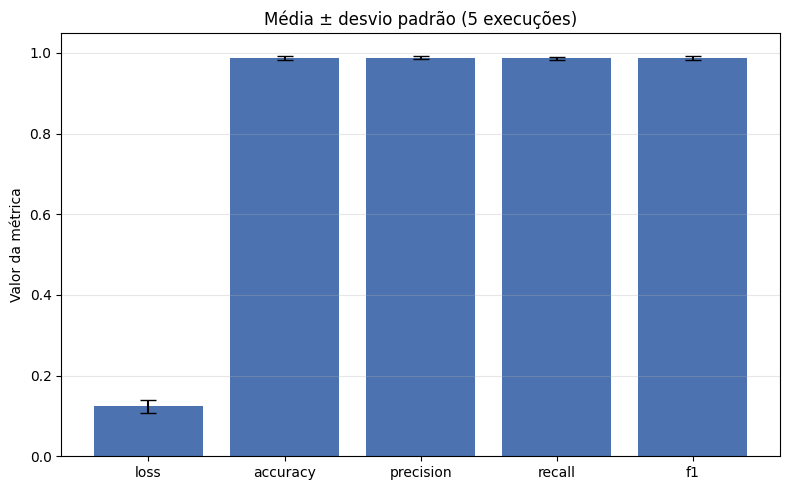

In [ ]:
# --------------------------------------------------------------
# 6.1. Recarrega os resultados salvos (garante que estamos usando
#      os dados mais atuais, mesmo que o notebook tenha sido reiniciado)
# --------------------------------------------------------------
with open(RESULTS_PATH, 'r') as f:
    resultados = json.load(f)

metricas = ["loss", "accuracy", "precision", "recall", "f1"]

# --------------------------------------------------------------
# 6.2. Para cada métrica: calcula média e desvio padrão AMOSTRAL (ddof=1)
#      ddof=1 é o mais indicado quando temos poucas execuções e queremos
#      estimar a variabilidade real do processo de treino.
# --------------------------------------------------------------
resumo = {}
print("=== Resumo das execuções (média ± desvio padrão) ===\n")
for m in metricas:
    valores = np.array([r[m] for r in resultados])
    media = valores.mean()
    desvio = valores.std(ddof=1) if len(valores) > 1 else 0.0
    resumo[m] = {"media": float(media), "desvio_padrao": float(desvio)}
    print(f"{m:>10s}: {media:.4f} ± {desvio:.4f}  (n={len(valores)})")

# --------------------------------------------------------------
# 6.3. Salva também o resumo (média/desvio) no Drive
# --------------------------------------------------------------
resumo_path = os.path.join(DADOS_DIR, 'resumo_metricas.json')
with open(resumo_path, 'w') as f:
    json.dump(resumo, f, indent=2)
print(f"\nResumo salvo em {resumo_path}")

# --------------------------------------------------------------
# 6.4. Visualização: barras de erro (média ± desvio padrão) por métrica
# --------------------------------------------------------------
plt.figure(figsize=(8, 5))
medias = [resumo[m]["media"] for m in metricas]
desvios = [resumo[m]["desvio_padrao"] for m in metricas]

plt.bar(metricas, medias, yerr=desvios, capsize=6, color='#4C72B0')
plt.ylabel("Valor da métrica")
plt.title(f"Média ± desvio padrão ({len(resultados)} execuções)")
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(DADOS_DIR, 'resumo_metricas_grafico.png'))
print(f"Gráfico salvo em {os.path.join(DADOS_DIR, 'resumo_metricas_grafico.png')}")

plt.show()


# 7. Matriz de confusão da melhor execução

Esta seção depende do que foi salvo nas seções 2 e 5:
- `test_paths.npy` / `test_labels.npy` (salvos na seção 2, junto com o split)
- `execucoes.json` e os modelos `.keras` de cada seed (salvos na seção 5)

Por padrão ela carrega o modelo com o **melhor F1** entre as execuções.
Redefine tudo que precisa (incluindo o mount do Drive), então pode ser rodada
sozinha, mesmo depois de reiniciar o ambiente de execução.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Colab cache for faster access to the 'brain-tumors-dataset' dataset.
Carregando modelo da seed=2024 (F1=0.9903) de /content/drive/MyDrive/Projeto/Desv_Hip/224x224/modelos_salvos/Desv_Hip_224_seed2024.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1136s 17s/step
Matriz de confusão salva em /content/drive/MyDrive/Projeto/Desv_Hip/224x224/resultados/matriz_confusao.png


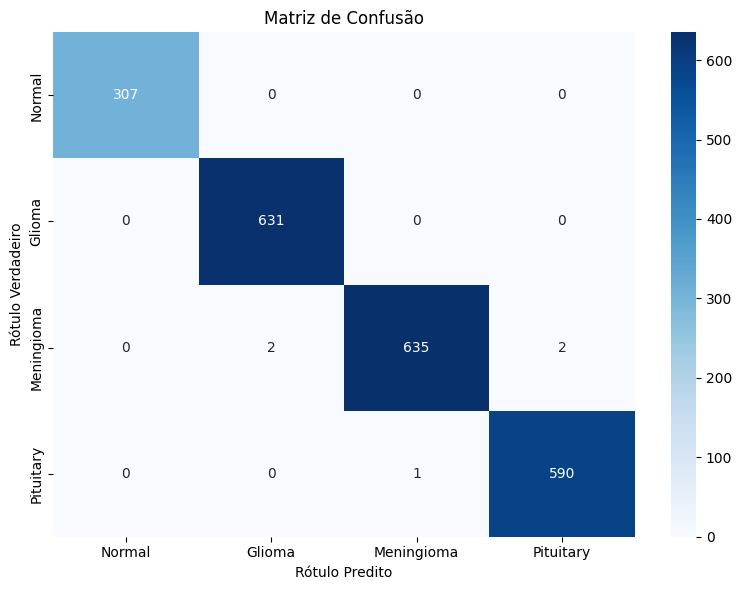

In [ ]:
# --------------------------------------------------------------
# 7.1. Mount do Drive, imports e pastas
#      Redefinidos aqui para esta célula funcionar mesmo sozinha, sem
#      precisar rodar os blocos 1-6 antes (ex.: numa sessão nova).
# --------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
import kagglehub
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = '/content/drive/MyDrive/Projeto/Desv_Hip'
RUN_DIR = os.path.join(BASE_DIR, '224x224')
DADOS_DIR = os.path.join(RUN_DIR, 'resultados')

# --------------------------------------------------------------
# 7.2. Carregar os caminhos/rótulos de teste salvos na seção 2 (bloco 2.4)
#      Este é o MESMO conjunto de teste usado em todas as execuções.
# --------------------------------------------------------------
test_paths_file = os.path.join(DADOS_DIR, 'test_paths.npy')
test_labels_file = os.path.join(DADOS_DIR, 'test_labels.npy')

if os.path.exists(test_paths_file) and os.path.exists(test_labels_file):
    test_paths = np.load(test_paths_file)
    test_labels = np.load(test_labels_file)
else:
    raise FileNotFoundError("Os arquivos test_paths.npy e test_labels.npy não foram encontrados no diretório.")

# Garante que o dataset está disponível (não baixa de novo se já tiver cache)
kagglehub.dataset_download("mohammadhossein77/brain-tumors-dataset")
# --------------------------------------------------------------
# 7.3. Escolher qual modelo carregar
#      Por padrão, pega automaticamente a execução (seed) com o MELHOR F1
#      dentre as salvas em execucoes.json (seção 5). Se preferir usar uma
#      seed específica, troque a linha marcada abaixo.
# --------------------------------------------------------------
RESULTS_PATH = os.path.join(DADOS_DIR, 'execucoes.json')
with open(RESULTS_PATH, 'r') as f:
    resultados = json.load(f)

melhor_execucao = max(resultados, key=lambda r: r['f1'])
# melhor_execucao = next(r for r in resultados if r['seed'] == 42)  # <- alternativa: escolher a seed manualmente

modelo_path = melhor_execucao['modelo_path']
print(f"Carregando modelo da seed={melhor_execucao['seed']} "
      f"(F1={melhor_execucao['f1']:.4f}) de {modelo_path}")

model = keras.models.load_model(modelo_path)

# --------------------------------------------------------------
# 7.4. Recriar a segmentação e o pipeline de dados EXATAMENTE como no
#      bloco 2 (Otsu + maior componente conectado + convex hull), para
#      a matriz de confusão refletir o mesmo pré-processamento usado
#      no treino/avaliação.
# --------------------------------------------------------------
IMAGE_SIZE = (224, 224)  # precisa bater com o IMAGE_SIZE usado no treino (bloco 2.1)

def segment_image_cv(image_tensor):
    img = image_tensor.numpy().astype(np.uint8) if hasattr(image_tensor, 'numpy') else image_tensor.astype(np.uint8)
    if len(img.shape) == 4:
        img = np.squeeze(img, axis=0)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    n_labels, labels_img, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=8)
    if n_labels > 1:
        maior_componente = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        thresh = np.where(labels_img == maior_componente, 255, 0).astype(np.uint8)

    contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contornos:
        maior_contorno = max(contornos, key=cv2.contourArea)
        hull = cv2.convexHull(maior_contorno)
        thresh_hull = np.zeros_like(thresh)
        cv2.drawContours(thresh_hull, [hull], -1, 255, thickness=cv2.FILLED)
        thresh = thresh_hull

    segmented = cv2.bitwise_and(img, img, mask=thresh)
    return segmented.astype(np.float32)

def create_tf_dataset(image_paths, labels, num_classes, batch_size=32):
    def load_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMAGE_SIZE)
        [img,] = tf.py_function(segment_image_cv, [img], [tf.float32])
        img.set_shape((IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
        return img, tf.one_hot(label, num_classes)
    return (tf.data.Dataset.from_tensor_slices((image_paths, labels))
            .map(load_image)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# --------------------------------------------------------------
# 7.5. Gerar previsões e montar a matriz de confusão
# --------------------------------------------------------------
num_classes = len(np.unique(test_labels))
test_ds = create_tf_dataset(test_paths, test_labels, num_classes)
y_pred = np.argmax(model.predict(test_ds), axis=1)

cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Glioma', 'Meningioma', 'Pituitary'],
            yticklabels=['Normal', 'Glioma', 'Meningioma', 'Pituitary'])
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Predito')
plt.tight_layout()

# --------------------------------------------------------------
# 7.6. Salvar a figura no Drive
# --------------------------------------------------------------
plt.savefig(os.path.join(DADOS_DIR, 'matriz_confusao.png'))
print(f"Matriz de confusão salva em {os.path.join(DADOS_DIR, 'matriz_confusao.png')}")

plt.show()


# TESTES DE SEGMENTAÇÃO

In [ ]:
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 2.8.1. Teste visual: mostra as etapas da segmentação, imagem por imagem
# --------------------------------------------------------------
def testar_segmentacao_visual(n_por_classe=2, seed=42):
    """
    Para algumas imagens de cada classe, mostra lado a lado:
    original -> escala de cinza -> máscara do Otsu -> imagem segmentada.
    """
    rng = np.random.default_rng(seed)
    amostras = []

    for classe in class_names_list:
        indices_classe = [i for i, lbl in enumerate(labels_raw) if lbl == classe]
        n = min(n_por_classe, len(indices_classe))
        escolhidos = rng.choice(indices_classe, size=n, replace=False)
        for idx in escolhidos:
            amostras.append((classe, image_paths_originais[idx]))

    n_linhas = len(amostras)
    fig, axes = plt.subplots(n_linhas, 4, figsize=(14, 3.2 * n_linhas))
    if n_linhas == 1:
        axes = axes.reshape(1, -1)

    titulos = ["Original", "Escala de cinza", "Máscara (Otsu)", "Segmentado"]

    for row, (classe, caminho) in enumerate(amostras):
        img_raw = tf.io.read_file(caminho)
        img_raw = tf.image.decode_jpeg(img_raw, channels=3)
        img_resized = tf.image.resize(img_raw, IMAGE_SIZE).numpy().astype(np.uint8)

        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (7, 7), 0)
        _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        segmentado = cv2.bitwise_and(img_resized, img_resized, mask=thresh)

        imagens = [img_resized, gray, thresh, segmentado]
        cmaps = [None, 'gray', 'gray', None]

        for col, (imagem, cmap) in enumerate(zip(imagens, cmaps)):
            axes[row, col].imshow(imagem, cmap=cmap)
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(titulos[col])
        axes[row, 0].set_ylabel(classe)

    plt.tight_layout()
    plt.show()

testar_segmentacao_visual(n_por_classe=2)

# --------------------------------------------------------------
# 2.8.2. Teste estatístico: varre uma amostra maior procurando falhas
# --------------------------------------------------------------
def testar_segmentacao_estatistico(n_amostras=200, seed=42,
                                    limite_baixo=0.02, limite_alto=0.90):
    """
    Roda a segmentação em uma amostra aleatória de imagens e calcula a
    fração de pixels mantida pela máscara em cada uma.
    """
    rng = np.random.default_rng(seed)
    n_amostras = min(n_amostras, len(image_paths_originais))
    indices = rng.choice(len(image_paths_originais), size=n_amostras, replace=False)

    fracoes = []
    suspeitas = []

    for idx in indices:
        caminho = image_paths_originais[idx]
        classe = labels_raw[idx]

        img_raw = tf.io.read_file(caminho)
        img_raw = tf.image.decode_jpeg(img_raw, channels=3)
        img_resized = tf.image.resize(img_raw, IMAGE_SIZE).numpy().astype(np.uint8)

        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (7, 7), 0)
        _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        fracao = (thresh > 0).mean()
        fracoes.append(fracao)

        if fracao < limite_baixo or fracao > limite_alto:
            suspeitas.append((caminho, classe, fracao))

    fracoes = np.array(fracoes)
    print(f"Amostra: {n_amostras} imagens")
    print(f"Fração de pixels mantida pela máscara — média: {fracoes.mean():.3f} "
          f"| mín: {fracoes.min():.3f} | máx: {fracoes.max():.3f}")
    print(f"Imagens suspeitas (fora de [{limite_baixo}, {limite_alto}]): "
          f"{len(suspeitas)} de {n_amostras} ({100 * len(suspeitas) / n_amostras:.1f}%)")

    if suspeitas:
        print("\nPrimeiras suspeitas encontradas:")
        for caminho, classe, fracao in suspeitas[:10]:
            print(f" - [{classe}] fração={fracao:.3f} | {caminho}")

    return fracoes, suspeitas

fracoes, suspeitas = testar_segmentacao_estatistico(n_amostras=200)


Amostras da segmentação para o artigo

In [ ]:
# --------------------------------------------------------------
# Amostra de segmentação: 1 imagem por classe (original, máscara, segmentado)
# --------------------------------------------------------------
def amostra_segmentacao_por_classe(seed=42):
    rng = np.random.default_rng(seed)
    amostras = []

    for classe in class_names_list:
        indices_classe = [i for i, lbl in enumerate(labels_raw) if lbl == classe]
        idx = rng.choice(indices_classe)
        amostras.append((classe, image_paths_originais[idx]))

    fig, axes = plt.subplots(len(amostras), 3, figsize=(10, 3.2 * len(amostras)))

    titulos = ["Original", "Máscara", "Segmentado"]

    for row, (classe, caminho) in enumerate(amostras):
        img_raw = tf.io.read_file(caminho)
        img_raw = tf.image.decode_jpeg(img_raw, channels=3)
        img_resized = tf.image.resize(img_raw, IMAGE_SIZE).numpy().astype(np.uint8)

        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
        blurred = cv2.GaussianBlur(gray, (7, 7), 0)
        _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        n_labels, labels_img, stats, _ = cv2.connectedComponentsWithStats(thresh, connectivity=8)
        if n_labels > 1:
            maior_componente = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
            thresh = np.where(labels_img == maior_componente, 255, 0).astype(np.uint8)
        contornos, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contornos:
            maior_contorno = max(contornos, key=cv2.contourArea)
            hull = cv2.convexHull(maior_contorno)
            mascara = np.zeros_like(thresh)
            cv2.drawContours(mascara, [hull], -1, 255, thickness=cv2.FILLED)
        else:
            mascara = thresh

        segmentado = segment_image_cv(img_resized).astype(np.uint8)

        imagens = [img_resized, mascara, segmentado]
        cmaps = [None, 'gray', None]

        for col, (imagem, cmap) in enumerate(zip(imagens, cmaps)):
            axes[row, col].imshow(imagem, cmap=cmap)
            axes[row, col].axis('off')
            if row == 0:
                axes[row, col].set_title(titulos[col])
        axes[row, 0].set_ylabel(classe, rotation=90, labelpad=10)

    plt.tight_layout()
    plt.show()
    return fig

fig = amostra_segmentacao_por_classe()
